# Italy/Rome — Viral Tourism Panel Dataset
**First database build** — Eurostat hotel nights + Wikipedia pageviews + Google Trends (2015–2024)

Key question: do online attention signals lead actual tourist arrivals?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings; warnings.filterwarnings("ignore")

panel = pd.read_csv("data/panel_italy.csv", parse_dates=["date"])
print(f"Shape: {panel.shape}")
panel.describe().round(0)

Shape: (133, 8)


,date,tourist_nights,wiki_italy,wiki_rome,wiki_tourism_italy,trend_italy_tourism,trend_visit_rome
count,133,133.0,113.0,113.0,113.0,120.0,120.0
mean,2020-07-01 07:34:44.210526208,20850974.0,406369.0,186853.0,8087.0,45.0,62.0
min,2015-01-01 00:00:00,596806.0,297409.0,128495.0,5303.0,24.0,14.0
25%,2017-10-01 00:00:00,12975556.0,333580.0,160515.0,6330.0,36.0,54.0
50%,2020-07-01 00:00:00,17244221.0,360767.0,179188.0,7505.0,42.0,65.0
75%,2023-04-01 00:00:00,29699317.0,436106.0,193323.0,9379.0,50.0,76.0
max,2026-01-01 00:00:00,46610828.0,1526421.0,574433.0,15541.0,100.0,100.0
std,NaN,12120534.0,148151.0,50012.0,2205.0,14.0,22.0


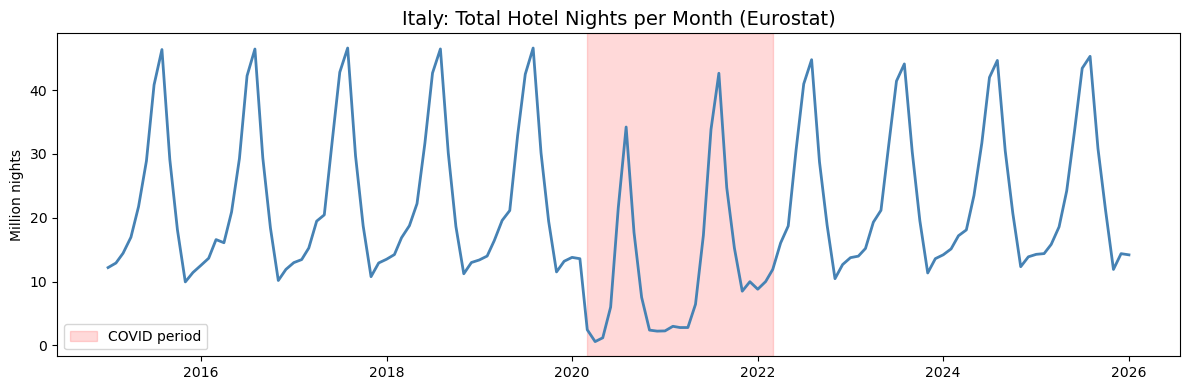

In [2]:
# Tourist nights — the dependent variable
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(panel["date"], panel["tourist_nights"] / 1e6, color="steelblue", linewidth=2)
ax.axvspan(pd.Timestamp("2020-03"), pd.Timestamp("2022-03"), alpha=0.15, color="red", label="COVID period")
ax.set_title("Italy: Total Hotel Nights per Month (Eurostat)", fontsize=14)
ax.set_ylabel("Million nights")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.legend(); plt.tight_layout(); plt.show()

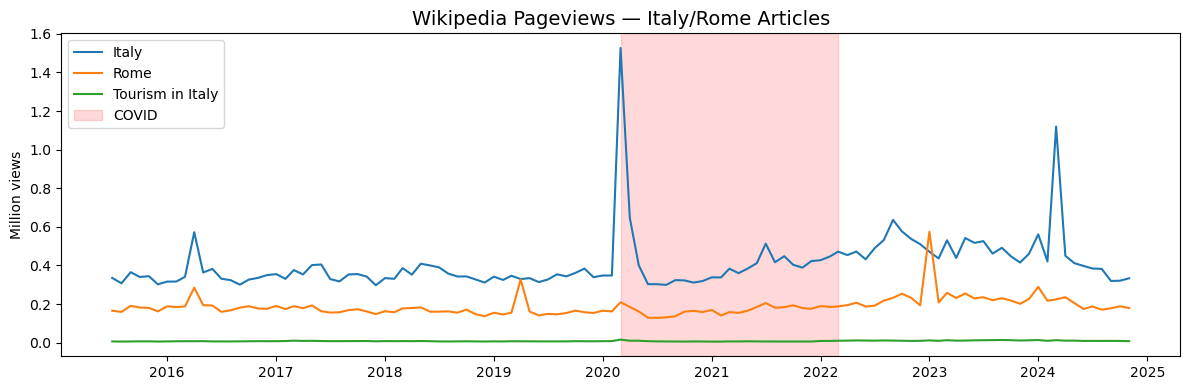

In [3]:
# Wikipedia pageviews — attention signals
fig, ax = plt.subplots(figsize=(12, 4))
for col, label, color in [("wiki_italy", "Italy", "steelblue"), ("wiki_rome", "Rome", "darkorange"), ("wiki_tourism_italy", "Tourism in Italy", "green")]:
    ax.plot(panel["date"], panel[col] / 1e6, label=label, linewidth=1.5)
ax.axvspan(pd.Timestamp("2020-03"), pd.Timestamp("2022-03"), alpha=0.15, color="red", label="COVID")
ax.set_title("Wikipedia Pageviews — Italy/Rome Articles", fontsize=14)
ax.set_ylabel("Million views")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.legend(); plt.tight_layout(); plt.show()

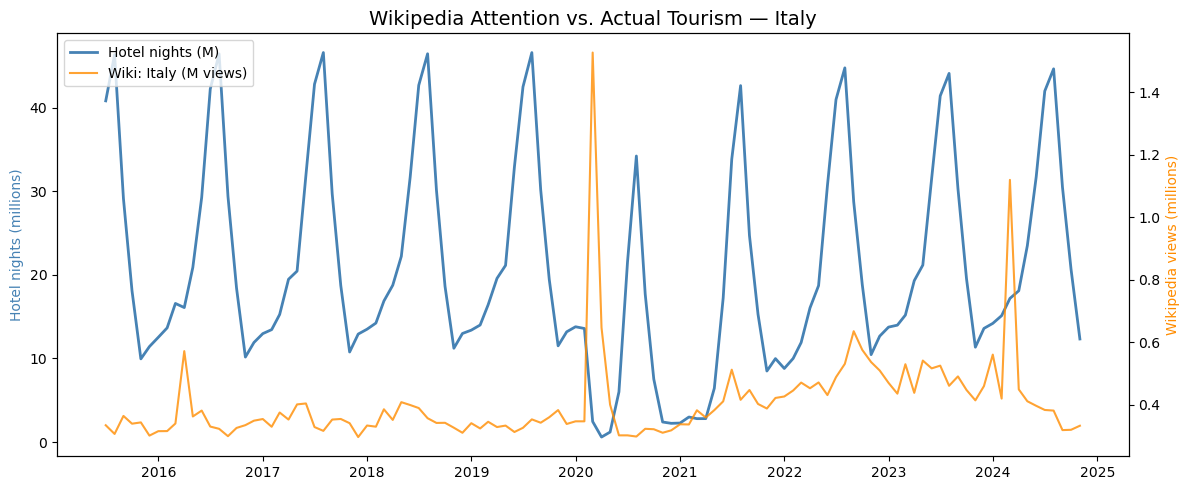

In [4]:
# Dual-axis: attention signal vs actual arrivals
df = panel.dropna(subset=["wiki_italy", "tourist_nights"])
fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()
ax1.plot(df["date"], df["tourist_nights"] / 1e6, color="steelblue", linewidth=2, label="Hotel nights (M)")
ax2.plot(df["date"], df["wiki_italy"] / 1e6, color="darkorange", linewidth=1.5, alpha=0.8, label="Wiki: Italy (M views)")
ax1.set_ylabel("Hotel nights (millions)", color="steelblue")
ax2.set_ylabel("Wikipedia views (millions)", color="darkorange")
ax1.set_title("Wikipedia Attention vs. Actual Tourism — Italy", fontsize=14)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout(); plt.show()

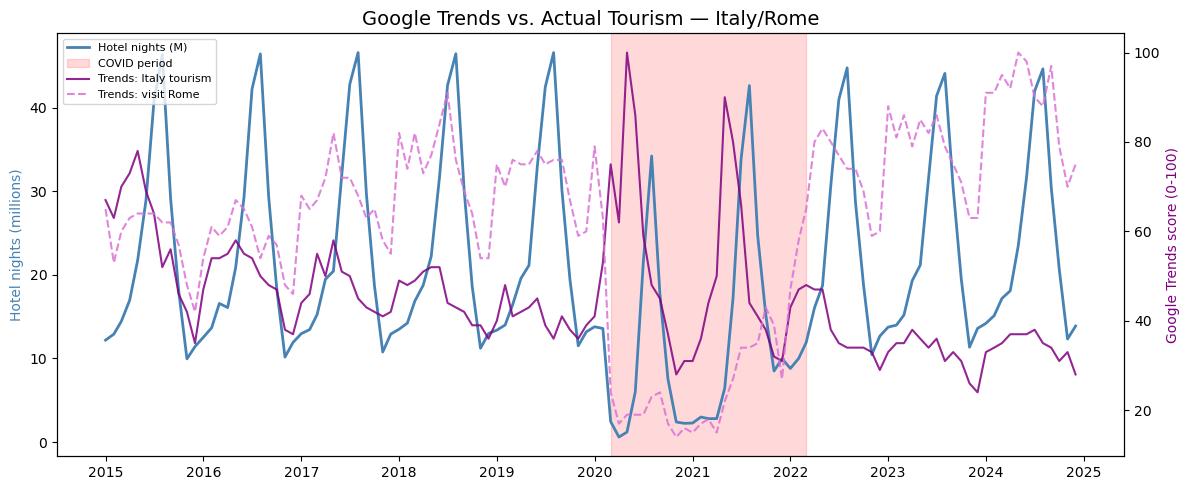

In [5]:
# Google Trends scores vs actual hotel nights — Italy
df = panel.dropna(subset=["trend_italy_tourism", "tourist_nights"])
fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()
ax1.plot(df["date"], df["tourist_nights"] / 1e6, color="steelblue", linewidth=2, label="Hotel nights (M)")
ax2.plot(df["date"], df["trend_italy_tourism"], color="purple", linewidth=1.5, alpha=0.85, label="Trends: Italy tourism")
ax2.plot(df["date"], df["trend_visit_rome"], color="orchid", linewidth=1.5, alpha=0.85, linestyle="--", label="Trends: visit Rome")
ax1.axvspan(pd.Timestamp("2020-03"), pd.Timestamp("2022-03"), alpha=0.15, color="red", label="COVID period")
ax1.set_ylabel("Hotel nights (millions)", color="steelblue")
ax2.set_ylabel("Google Trends score (0-100)", color="purple")
ax1.set_title("Google Trends vs. Actual Tourism — Italy/Rome", fontsize=14)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=8)
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout(); plt.show()

Correlation matrix:
                     tourist_nights  wiki_italy  wiki_rome  \
tourist_nights                 1.00       -0.10      -0.04   
wiki_italy                    -0.10        1.00       0.34   
wiki_rome                     -0.04        0.34       1.00   
wiki_tourism_italy             0.00        0.64       0.52   
trend_italy_tourism           -0.08        0.06      -0.21   
trend_visit_rome               0.46        0.06       0.33   

                     wiki_tourism_italy  trend_italy_tourism  trend_visit_rome  
tourist_nights                     0.00                -0.08              0.46  
wiki_italy                         0.64                 0.06              0.06  
wiki_rome                          0.52                -0.21              0.33  
wiki_tourism_italy                 1.00                -0.16              0.45  
trend_italy_tourism               -0.16                 1.00             -0.32  
trend_visit_rome                   0.45                -0.3

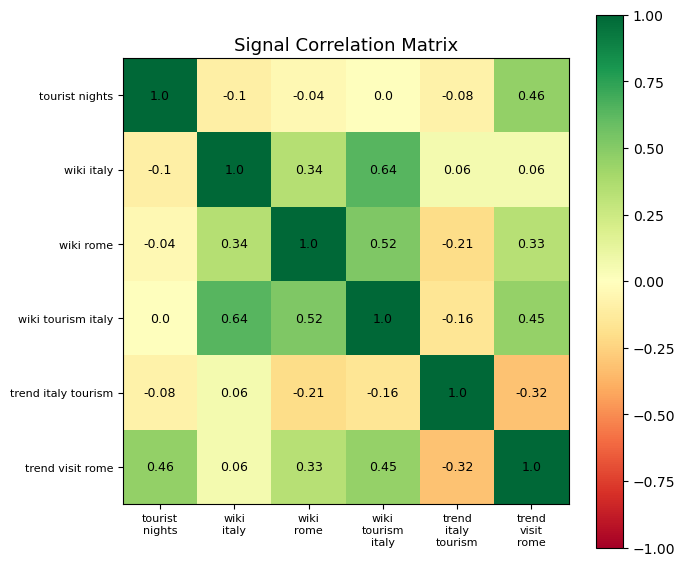

In [6]:
# Correlation matrix — are signals correlated with actual arrivals?
cols = ["tourist_nights", "wiki_italy", "wiki_rome", "wiki_tourism_italy", "trend_italy_tourism", "trend_visit_rome"]
corr = panel[cols].corr().round(2)
print("Correlation matrix:")
print(corr)

import matplotlib.pyplot as plt
import numpy as np
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr, cmap="RdYlGn", vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(cols))); ax.set_xticklabels([c.replace("_", "\n") for c in cols], fontsize=8)
ax.set_yticks(range(len(cols))); ax.set_yticklabels([c.replace("_", " ") for c in cols], fontsize=8)
for i in range(len(cols)):
    for j in range(len(cols)):
        ax.text(j, i, str(corr.iloc[i, j]), ha="center", va="center", fontsize=9)
ax.set_title("Signal Correlation Matrix", fontsize=13)
plt.tight_layout(); plt.show()

## Japan — JNTO Inbound Visitors + Wikipedia + Google Trends
Data source: Japan National Tourism Organization (JNTO), monthly inbound visitor counts 2015–2024.
Japan kept its borders **completely closed** until October 2022 — the reopening spike is a clean natural experiment.

In [7]:
import pandas as pd, matplotlib.pyplot as plt, matplotlib.dates as mdates

jp = pd.read_csv("data/panel_japan.csv", parse_dates=["date"])
print(f"Shape: {jp.shape}")
jp.describe().round(0)

Shape: (120, 7)


,date,inbound_visitors,wiki_japan,wiki_tourism_japan,trend_japan_travel,trend_visit_japan
count,120,120.0,113.0,113.0,120.0,120.0
mean,2019-12-16 10:48:00,1713937.0,593303.0,6807.0,39.0,20.0
min,2015-01-01 00:00:00,1663.0,421532.0,3599.0,20.0,5.0
25%,2017-06-23 12:00:00,203395.0,497248.0,5385.0,30.0,8.0
50%,2019-12-16 12:00:00,2042502.0,528115.0,7083.0,36.0,10.0
75%,2022-06-08 12:00:00,2583014.0,676675.0,7932.0,47.0,13.0
max,2024-12-01 00:00:00,3489888.0,1077697.0,10224.0,100.0,100.0
std,NaN,1099087.0,137089.0,1548.0,14.0,23.0


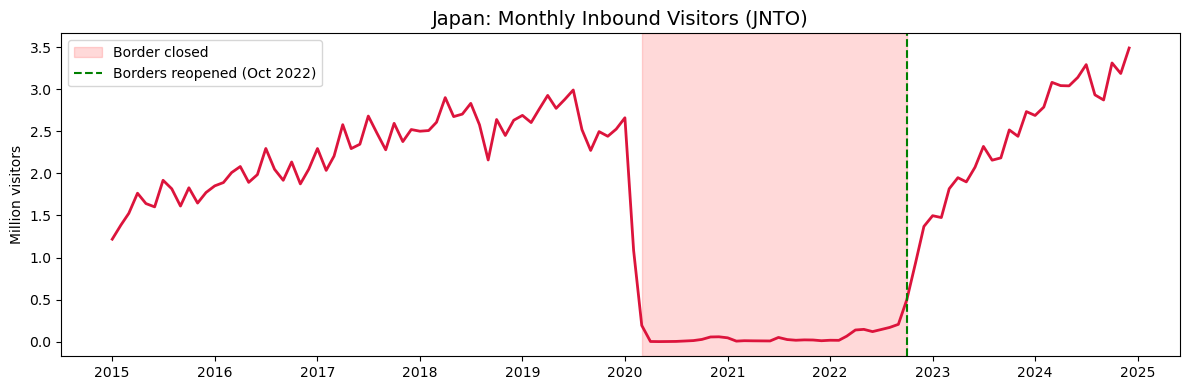

In [8]:
# Inbound visitors — the dramatic COVID closure and 2022 reopening boom
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(jp["date"], jp["inbound_visitors"] / 1e6, color="crimson", linewidth=2)
ax.axvspan(pd.Timestamp("2020-03"), pd.Timestamp("2022-10"), alpha=0.15, color="red", label="Border closed")
ax.axvline(pd.Timestamp("2022-10"), color="green", linestyle="--", linewidth=1.5, label="Borders reopened (Oct 2022)")
ax.set_title("Japan: Monthly Inbound Visitors (JNTO)", fontsize=14)
ax.set_ylabel("Million visitors")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.legend(); plt.tight_layout(); plt.show()

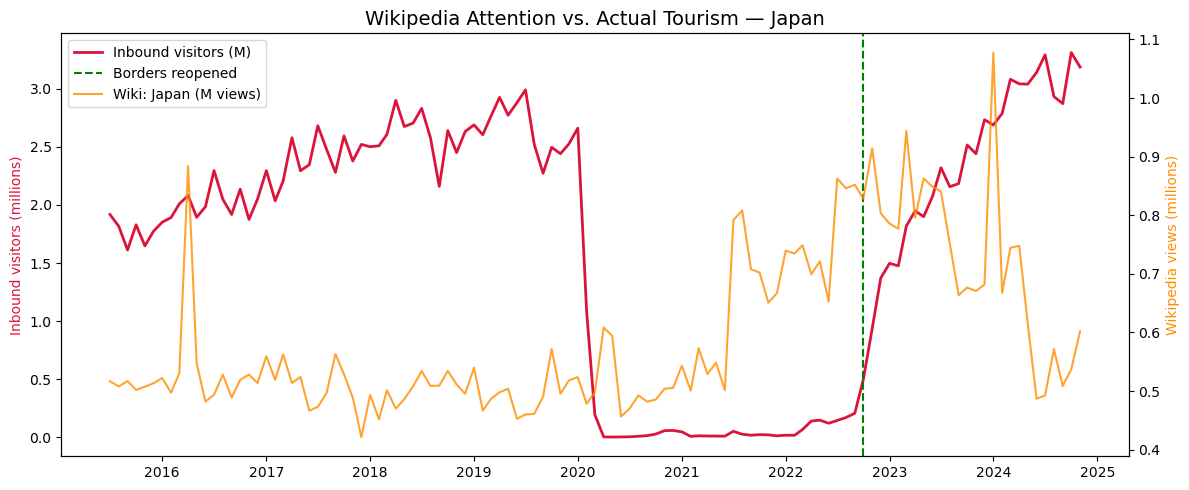

In [9]:
# Dual-axis: Wikipedia attention vs actual visitors
df = jp.dropna(subset=["wiki_japan", "inbound_visitors"])
fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()
ax1.plot(df["date"], df["inbound_visitors"] / 1e6, color="crimson", linewidth=2, label="Inbound visitors (M)")
ax2.plot(df["date"], df["wiki_japan"] / 1e6, color="darkorange", linewidth=1.5, alpha=0.8, label="Wiki: Japan (M views)")
ax1.axvline(pd.Timestamp("2022-10"), color="green", linestyle="--", linewidth=1.5, label="Borders reopened")
ax1.set_ylabel("Inbound visitors (millions)", color="crimson")
ax2.set_ylabel("Wikipedia views (millions)", color="darkorange")
ax1.set_title("Wikipedia Attention vs. Actual Tourism — Japan", fontsize=14)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout(); plt.show()

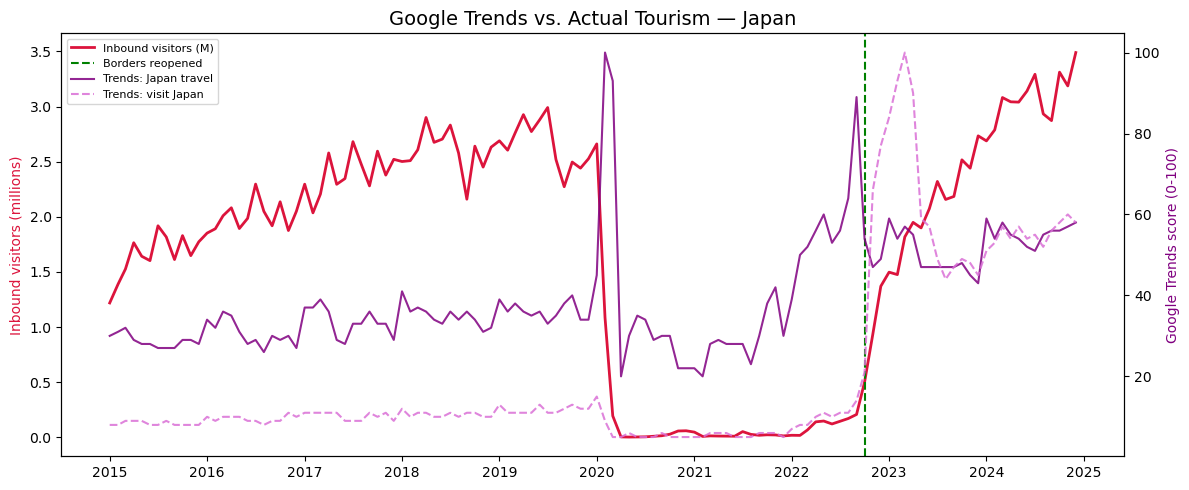

In [10]:
# Google Trends scores vs actual inbound visitors — Japan
df = jp.dropna(subset=["trend_japan_travel", "inbound_visitors"])
fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()
ax1.plot(df["date"], df["inbound_visitors"] / 1e6, color="crimson", linewidth=2, label="Inbound visitors (M)")
ax2.plot(df["date"], df["trend_japan_travel"], color="purple", linewidth=1.5, alpha=0.85, label="Trends: Japan travel")
ax2.plot(df["date"], df["trend_visit_japan"], color="orchid", linewidth=1.5, alpha=0.85, linestyle="--", label="Trends: visit Japan")
ax1.axvline(pd.Timestamp("2022-10"), color="green", linestyle="--", linewidth=1.5, label="Borders reopened")
ax1.set_ylabel("Inbound visitors (millions)", color="crimson")
ax2.set_ylabel("Google Trends score (0-100)", color="purple")
ax1.set_title("Google Trends vs. Actual Tourism — Japan", fontsize=14)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=8)
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout(); plt.show()

Japan correlation matrix:
                    inbound_visitors  wiki_japan  wiki_tourism_japan  \
inbound_visitors                1.00       -0.25                0.83   
wiki_japan                     -0.25        1.00               -0.36   
wiki_tourism_japan              0.83       -0.36                1.00   
trend_japan_travel              0.07        0.45               -0.04   
trend_visit_japan               0.35        0.54                0.15   

                    trend_japan_travel  trend_visit_japan  
inbound_visitors                  0.07               0.35  
wiki_japan                        0.45               0.54  
wiki_tourism_japan               -0.04               0.15  
trend_japan_travel                1.00               0.51  
trend_visit_japan                 0.51               1.00  


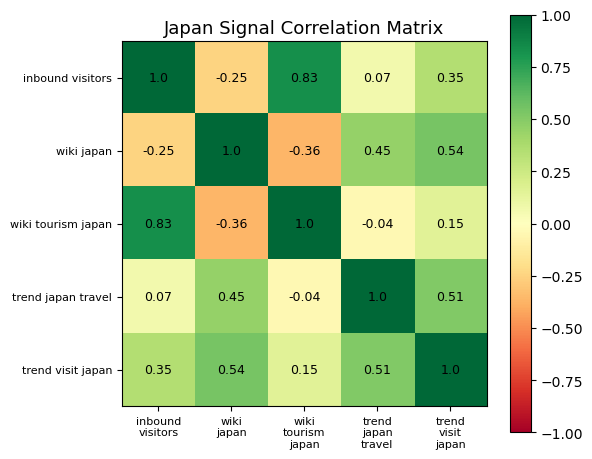

In [11]:
# Correlation matrix — Japan signals
cols = ["inbound_visitors", "wiki_japan", "wiki_tourism_japan", "trend_japan_travel", "trend_visit_japan"]
corr = jp[cols].corr().round(2)
print("Japan correlation matrix:")
print(corr)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr, cmap="RdYlGn", vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(cols))); ax.set_xticklabels([c.replace("_", "\n") for c in cols], fontsize=8)
ax.set_yticks(range(len(cols))); ax.set_yticklabels([c.replace("_", " ") for c in cols], fontsize=8)
for i in range(len(cols)):
    for j in range(len(cols)):
        ax.text(j, i, str(corr.iloc[i, j]), ha="center", va="center", fontsize=9)
ax.set_title("Japan Signal Correlation Matrix", fontsize=13)
plt.tight_layout(); plt.show()